# IoT Intrusion Detection — Feature Selection and Optimization

### Objective
Rank all processed features using **training data only** and build the
10/15/20/30/All feature subsets that every model notebook after this one
compares. Four independent ranking methods are combined into one defensible
consensus ranking, rather than trusting any single method alone.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import PROCESSED_DIR, FEATSEL_DIR, FIGURES_DIR, REPORT_SUPPORT_DIR, RANDOM_STATE

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

## 1. Load Training Data

Only the training split is used for ranking — the validation and test sets
play no role in deciding which features matter.

In [2]:
def load_training_data():
    X_train = pd.read_csv(PROCESSED_DIR / "X_train_tree.csv")
    y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["Label"]
    return X_train, y_train


X_train, y_train = load_training_data()
print(f"Training data: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
sw_train = compute_sample_weight(class_weight="balanced", y=y_train)

Training data: 295,484 rows x 72 features


## 2. ANOVA F-Test

In [3]:
def compute_anova_scores(X, y):
    f_scores, p_values = f_classif(X, y)
    return pd.DataFrame({"feature": X.columns, "anova_f_score": f_scores, "anova_p_value": p_values})


anova_df = compute_anova_scores(X_train, y_train)
print(anova_df.sort_values("anova_f_score", ascending=False).head(10).to_string(index=False))

         feature  anova_f_score  anova_p_value
        Dst_Port   87787.966549            0.0
 Fwd_Pkt_Len_Std   36233.178024            0.0
    ACK_Flag_Cnt   28974.392592            0.0
        Src_Port   20372.881214            0.0
 Fwd_Pkt_Len_Max   15544.491907            0.0
        Protocol   15099.833298            0.0
Subflow_Fwd_Byts   11270.384217            0.0
 TotLen_Fwd_Pkts   11270.384217            0.0
Fwd_Pkt_Len_Mean    9582.648507            0.0
Fwd_Seg_Size_Avg    9582.648507            0.0


## 3. Mutual Information

Estimated on a reproducible 50,000-row training sample to bound runtime —
still training data only, never validation/test.

In [4]:
def compute_mutual_information(X, y, sample_n=50000, random_state=RANDOM_STATE):
    if len(X) > sample_n:
        X_s = X.sample(n=sample_n, random_state=random_state)
        y_s = y.loc[X_s.index]
    else:
        X_s, y_s = X, y
    mi = mutual_info_classif(X_s, y_s, random_state=random_state)
    return pd.DataFrame({"feature": X.columns, "mutual_info": mi})


mi_df = compute_mutual_information(X_train, y_train)
print(mi_df.sort_values("mutual_info", ascending=False).head(10).to_string(index=False))

          feature  mutual_info
         Dst_Port     0.233076
         Src_Port     0.208105
    Flow_Duration     0.170414
      Flow_Pkts/s     0.149381
        Idle_Mean     0.137199
    Flow_IAT_Mean     0.134492
         Idle_Max     0.129692
     Flow_IAT_Max     0.127383
Init_Bwd_Win_Byts     0.122612
       Bwd_Pkts/s     0.122590


## 4. Tree-Based Importance (Random Forest and XGBoost)

In [5]:
def compute_tree_importance(X, y, sample_weight):
    rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight="balanced_subsample",
                                 n_jobs=-1, random_state=RANDOM_STATE)
    rf.fit(X, y)
    xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method="hist",
                                   random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")
    xgb_model.fit(X, y, sample_weight=sample_weight)
    return (pd.DataFrame({"feature": X.columns, "rf_importance": rf.feature_importances_}),
            pd.DataFrame({"feature": X.columns, "xgb_importance": xgb_model.feature_importances_}))


rf_imp_df, xgb_imp_df = compute_tree_importance(X_train, y_train, sw_train)
print("RF top 10:\n", rf_imp_df.sort_values("rf_importance", ascending=False).head(10).to_string(index=False))
print("\nXGB top 10:\n", xgb_imp_df.sort_values("xgb_importance", ascending=False).head(10).to_string(index=False))

RF top 10:
           feature  rf_importance
         Dst_Port       0.203122
         Src_Port       0.116933
Init_Bwd_Win_Byts       0.092445
    Flow_Duration       0.074939
     ACK_Flag_Cnt       0.053861
      Flow_Pkts/s       0.053314
   Bwd_Header_Len       0.034052
     Flow_IAT_Max       0.031592
         Idle_Max       0.023721
    Flow_IAT_Mean       0.021729

XGB top 10:
           feature  xgb_importance
      Bwd_IAT_Std        0.524098
         Dst_Port        0.165325
     ACK_Flag_Cnt        0.157297
    Flow_Duration        0.035348
      Bwd_IAT_Tot        0.020030
         Src_Port        0.019563
  Fwd_Pkt_Len_Min        0.008210
      Flow_Byts/s        0.005407
      Pkt_Len_Max        0.005138
Init_Bwd_Win_Byts        0.004518


### Observation
The four methods do not agree on a single "best" feature — ANOVA and mutual
information capture univariate relationships, while the tree-based methods
capture interactions and non-linear splits. This disagreement is expected
and is exactly why the final ranking below combines all four rather than
trusting one.

## 5. Normalize and Combine Into One Ranking

In [6]:
def normalize_importance_scores(df, col):
    lo, hi = df[col].min(), df[col].max()
    df[f"{col}_norm"] = (df[col] - lo) / (hi - lo) if hi > lo else 0.0
    return df


def combine_rankings(anova_df, mi_df, rf_df, xgb_df):
    merged = anova_df.merge(mi_df, on="feature").merge(rf_df, on="feature").merge(xgb_df, on="feature")
    merged = normalize_importance_scores(merged, "anova_f_score")
    merged = normalize_importance_scores(merged, "mutual_info")
    merged = normalize_importance_scores(merged, "rf_importance")
    merged = normalize_importance_scores(merged, "xgb_importance")
    merged["combined_score"] = merged[["anova_f_score_norm", "mutual_info_norm",
                                        "rf_importance_norm", "xgb_importance_norm"]].mean(axis=1)
    merged["rank"] = merged["combined_score"].rank(ascending=False, method="first").astype(int)
    return merged.sort_values("rank").reset_index(drop=True)


feature_ranking = combine_rankings(anova_df, mi_df, rf_imp_df, xgb_imp_df)
print(feature_ranking[["rank", "feature", "combined_score", "anova_f_score", "mutual_info",
                        "rf_importance", "xgb_importance"]].head(15).to_string(index=False))

 rank           feature  combined_score  anova_f_score  mutual_info  rf_importance  xgb_importance
    1          Dst_Port        0.828862   87787.966549     0.233076       0.203122        0.165325
    2          Src_Port        0.434484   20372.881214     0.208105       0.116933        0.019563
    3      ACK_Flag_Cnt        0.296756   28974.392592     0.067984       0.053861        0.157297
    4     Flow_Duration        0.292921     364.130766     0.170414       0.074939        0.035348
    5       Bwd_IAT_Std        0.279594      14.538298     0.023089       0.003889        0.524098
    6 Init_Bwd_Win_Byts        0.267321    6977.511339     0.122612       0.092445        0.004518
    7       Flow_Pkts/s        0.236358    2935.178405     0.149381       0.053314        0.004516
    8      Flow_IAT_Max        0.177395     549.169169     0.127383       0.031592        0.000663
    9         Idle_Mean        0.176474     821.977191     0.137199       0.021350        0.001456
   10     

## 6. Feature Ranking Plot

Saved: figures/feature_ranking.png


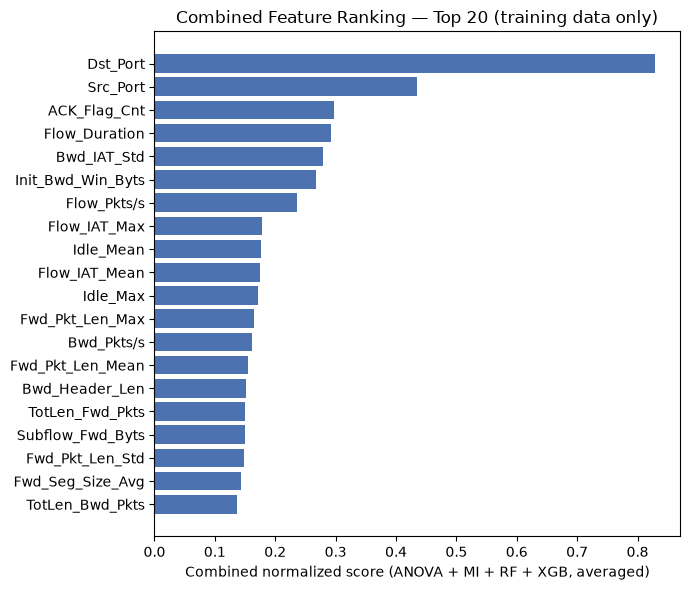

In [7]:
def plot_feature_ranking(ranking_df, top_n=20):
    top = ranking_df.head(top_n).sort_values("combined_score")
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(top["feature"], top["combined_score"], color="#4C72B0")
    ax.set_title(f"Combined Feature Ranking — Top {top_n} (training data only)")
    ax.set_xlabel("Combined normalized score (ANOVA + MI + RF + XGB, averaged)")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "feature_ranking.png", bbox_inches="tight")
    print("Saved: figures/feature_ranking.png")
    plt.show()


plot_feature_ranking(feature_ranking)

## 7. Create and Save Feature Sets

In [8]:
def create_feature_sets(ranking_df):
    ranked_features = ranking_df["feature"].tolist()
    return {
        10: ranked_features[:10], 15: ranked_features[:15], 20: ranked_features[:20],
        30: ranked_features[:30], "All": ranked_features,
    }


def save_feature_ranking(ranking_df):
    ranking_df.to_csv(FEATSEL_DIR / "feature_ranking.csv", index=False)
    print("Saved: feature_selection/feature_ranking.csv")


def save_feature_lists(feature_sets):
    for k, feats in feature_sets.items():
        name = f"top_{k}_features.txt" if k != "All" else "all_selected_features.txt"
        (FEATSEL_DIR / name).write_text("\n".join(feats), encoding="utf-8")
        print(f"Saved: feature_selection/{name}  ({len(feats)} features)")


feature_sets = create_feature_sets(feature_ranking)
save_feature_ranking(feature_ranking)
save_feature_lists(feature_sets)

Saved: feature_selection/feature_ranking.csv
Saved: feature_selection/top_10_features.txt  (10 features)
Saved: feature_selection/top_15_features.txt  (15 features)
Saved: feature_selection/top_20_features.txt  (20 features)
Saved: feature_selection/top_30_features.txt  (30 features)
Saved: feature_selection/all_selected_features.txt  (72 features)


## 8. Report-Support Summary

In [9]:
selection_method = "Combined consensus of ANOVA F-test, mutual information, Random Forest " \
                    "importance, and XGBoost importance (min-max normalized, averaged), all " \
                    "computed on training data only."
rationale_by_k = {
    10: "Smallest lightweight subset for efficiency comparison.",
    15: "Modest expansion to check marginal gains over the top-10 subset.",
    20: "Further expansion; typical 'moderate' feature-count baseline.",
    30: "Larger subset approaching diminishing returns.",
    "All": "Full processed feature set — upper-bound reference for comparison.",
}
rows = []
for k, feats in feature_sets.items():
    rows.append({
        "Feature_Count": k if k != "All" else len(feature_ranking),
        "Feature_Set_Name": f"top_{k}" if k != "All" else "all_selected",
        "Features": ";".join(feats),
        "Selection_Method": selection_method,
        "Validation_Rationale": rationale_by_k[k],
    })
selected_features_summary = pd.DataFrame(rows)
selected_features_summary.to_csv(REPORT_SUPPORT_DIR / "selected_features_summary.csv", index=False)
print("Saved: report_support/selected_features_summary.csv")

Saved: report_support/selected_features_summary.csv


## Notebook Summary

In [10]:
from IPython.display import display, Markdown

summary_md = f"""
- Ranked all {len(feature_ranking)} processed features using **training data
  only**, combining ANOVA F-test, mutual information, Random Forest
  importance, and XGBoost importance into one consensus score.
- Top-ranked feature: **{feature_ranking.iloc[0]['feature']}**
  (combined score {feature_ranking.iloc[0]['combined_score']:.3f}).
- Built and saved feature subsets of size 10 / 15 / 20 / 30 / All to
  `feature_selection/` for every model notebook (06, 08, 09) to reuse
  identically — no notebook re-derives its own ranking.
- Saved `feature_selection/feature_ranking.csv`, `figures/feature_ranking.png`,
  and `report_support/selected_features_summary.csv`.

**Next notebook (`05_Gradient_Descent_Binary_Classification.ipynb`)** implements
binary logistic regression from scratch as an educational demonstration, before
the main scikit-learn-based classifiers (06-09) each run their own
10/15/20/30/All feature-count experiments using these saved feature lists.
"""
display(Markdown(summary_md))


- Ranked all 72 processed features using **training data
  only**, combining ANOVA F-test, mutual information, Random Forest
  importance, and XGBoost importance into one consensus score.
- Top-ranked feature: **Dst_Port**
  (combined score 0.829).
- Built and saved feature subsets of size 10 / 15 / 20 / 30 / All to
  `feature_selection/` for every model notebook (06, 08, 09) to reuse
  identically — no notebook re-derives its own ranking.
- Saved `feature_selection/feature_ranking.csv`, `figures/feature_ranking.png`,
  and `report_support/selected_features_summary.csv`.

**Next notebook (`05_Gradient_Descent_Binary_Classification.ipynb`)** implements
binary logistic regression from scratch as an educational demonstration, before
the main scikit-learn-based classifiers (06-09) each run their own
10/15/20/30/All feature-count experiments using these saved feature lists.
